In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of nndct_UNet failed: Traceback (most recent call last):
  File "/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/site-packages/IPython/extensions/autoreload.py", line 245, in check
    superreload(m, reload, self.old_objects)
  File "/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/site-packages/IPython/extensions/autoreload.py", line 394, in superreload
    module = reload(module)
  File "/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/imp.py", line 314, in reload
    return importlib.reload(module)
  File "/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/importlib/__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'nndct_UNet'
]


<h1><b>EVALUATION</b></h1>
<p>evaluation.ipynb</p>

In [20]:
import os

def is_vitis_ai_env():
    try:
        import pytorch_nndct
        return True
    except ImportError:
        return False

<h2>Load Model and Device</h2>

In [21]:
MODEL_NAME = "MDE_UNET"

import os


from src.model import UNet 

model_dir = os.path.join("./models", MODEL_NAME)
model_path = os.path.join(model_dir, MODEL_NAME + ".pth")

outputs_dir_path = os.path.join(model_dir, "outputs")
if not os.path.exists(outputs_dir_path):
    os.makedirs(outputs_dir_path)



In [22]:
import torch
import src.utils

from src.model import UNet

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model, history = src.utils.load_for_eval(UNet, MODEL_NAME, device)
model.eval()

	|- Model :
	|	|- Loading checkpoint from './models/MDE_UNET/MDE_UNET.pth'...
	|	|- Model state restored successfully (epoch 23).
	|	|- Loading training history from './models/MDE_UNET/MDE_UNET_history.json'.


UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     

<h2><b>Visual Representations</b></h2>

In [23]:
if not is_vitis_ai_env():

    import os
    import torch

    output_save_path = os.path.join(outputs_dir_path, "model_structure")

    try:
        from torchview import draw_graph
        model_graph = draw_graph(model, input_size=(2, 3, 224, 224), expand_nested=True)
        model_graph.visual_graph.render(filename=output_save_path, format='png')
        print(f"\t|- Model structure graph saved to '{output_save_path}.png'")
    except ImportError as e:
        print(f"\t|- [WARNING] torchview not available, skipping graph rendering: {e}")
    except Exception as e:
        print(f"\t|- [WARNING] Failed to generate model graph: {e}")

    onnx_save_path = os.path.join(outputs_dir_path, "model.onnx")

    try:
        dummy_input = torch.randn(2, 3, 224, 224, device=device)
        model.eval()
        torch.onnx.export(
            model,
            dummy_input,
            onnx_save_path,
            export_params=True,
            opset_version=17,
            do_constant_folding=True,
            input_names=['input'],
            output_names=['output'],
            dynamic_axes={
                'input': {0: 'batch_size'},
                'output': {0: 'batch_size'},
            },
        )
        print(f"\t|- ONNX model exported to '{onnx_save_path}'")
        #https://netron.app/ <- to display the onnx file
    except Exception as e:
        print(f"\t|- [WARNING] Failed to export ONNX model: {e}")

else:
    print("This cell function more easily outside vitis-ai environment")

This cell function more easily outside vitis-ai environment


<h2><b>Training Report</b></h2>

In [24]:
num_epochs = len(history['loss_train'])

print("=== STATISTICS - TRAINING REPORT ===")
print(f"Epochs          : {num_epochs}")
if num_epochs > 0:
    print(f"Training time   : {sum(history['epoch_time'])/60.0:.2f} minutes")


=== STATISTICS - TRAINING REPORT ===
Epochs          : 23
Training time   : 373.87 minutes


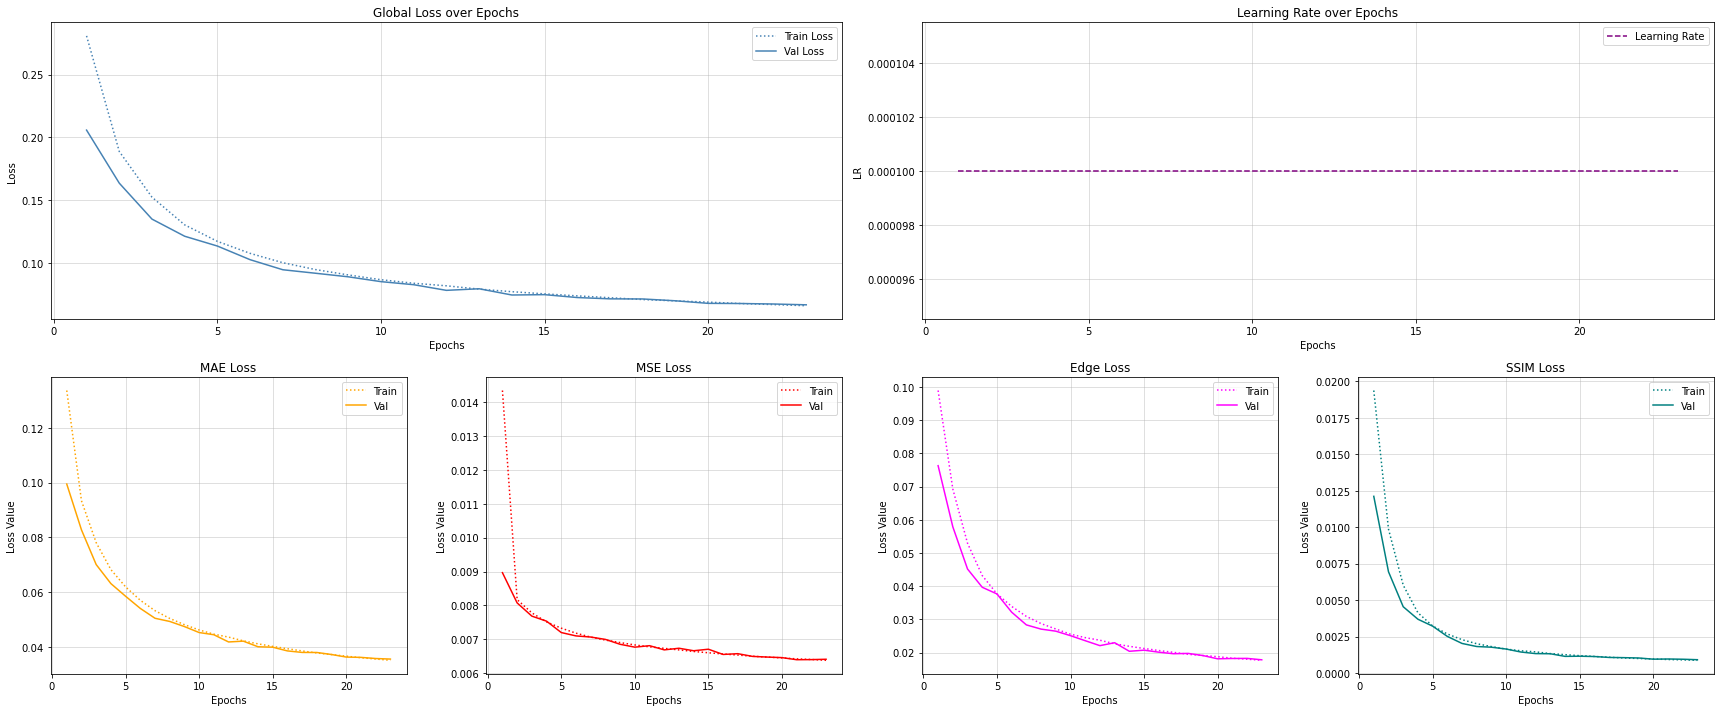

In [25]:
import matplotlib.pyplot as plt
import os

epochs = range(1, num_epochs + 1)

#--- consistent color per loss component (train and val share the same color)
component_colors = {
    'MAE': 'orange',
    'MSE': 'red',
    'Edge': 'magenta',
    'SSIM': 'teal',
}

component_keys = {
    'MAE': ('MAE_train', 'MAE_val'),
    'MSE': ('MSE_train', 'MSE_val'),
    'Edge': ('Edge_train', 'Edge_val'),
    'SSIM': ('SSIM_train', 'SSIM_val'),
}

fig = plt.figure(figsize=(24, 10))
gs = fig.add_gridspec(2, 4)

#--- 1. Global loss (train/val) -- top row, spans first 2 columns
ax_loss = fig.add_subplot(gs[0, 0:2])
ax_loss.plot(epochs, history['loss_train'], label='Train Loss', linestyle=':', color='steelblue')
ax_loss.plot(epochs, history['loss_val'], label='Val Loss', linestyle='-', color='steelblue')
ax_loss.set_title('Global Loss over Epochs')
ax_loss.set_xlabel('Epochs')
ax_loss.set_ylabel('Loss')
ax_loss.legend()
ax_loss.grid(True, alpha=0.5)

#--- 2. Learning rate -- top row, spans last 2 columns
ax_lr = fig.add_subplot(gs[0, 2:4])
ax_lr.plot(epochs, history['lr'], label='Learning Rate', color='purple', linestyle='--')
ax_lr.set_title('Learning Rate over Epochs')
ax_lr.set_xlabel('Epochs')
ax_lr.set_ylabel('LR')
ax_lr.legend()
ax_lr.grid(True, alpha=0.5)

#--- 3. One subplot per loss component -- bottom row
for i, (name, (train_key, val_key)) in enumerate(component_keys.items()):
    ax = fig.add_subplot(gs[1, i])
    color = component_colors[name]
    has_data = False

    if len(history.get(train_key, [])) > 0:
        ax.plot(epochs, history[train_key], label='Train', linestyle=':', color=color)
        has_data = True
    if len(history.get(val_key, [])) > 0:
        ax.plot(epochs, history[val_key], label='Val', linestyle='-', color=color)
        has_data = True

    if has_data:
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No data\navailable',
                horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)

    ax.set_title(f'{name} Loss')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss Value')
    ax.grid(True, alpha=0.5)

plt.tight_layout()
output_save_path = os.path.join(outputs_dir_path, "training_report.png")
plt.savefig(output_save_path, dpi=300, bbox_inches="tight", transparent=False)
plt.show()

---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
/tmp/ipykernel_135/28612126.py in <module>
      1 from random import randint
      2 
----> 3 img, dep = test_dataset[randint(0, len(test_dataset)-1)]
      4 
      5 print("=== STATISTICS - IMAGE RGB ===")

/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/random.py in randint(self, a, b)
    220         """
    221 
--> 222         return self.randrange(a, b+1)
    223 
    224     def _randbelow(self, n, int=int, maxsize=1<<BPF, type=type,

/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/random.py in randrange(self, start, stop, step, _int)
    198             return istart + self._randbelow(width)
    199         if step == 1:
--> 200             raise ValueError("empty range for randrange() (%d,%d, %d)" % (istart, istop, width))
    201 
    202         # Non-unit step argument supplied.

ValueError: empty range for randrange() (0,0, 0)---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
/tmp/ipykernel_135/28612126.py in <module>
      1 from random import randint
      2 
----> 3 img, dep = test_dataset[randint(0, len(test_dataset)-1)]
      4 
      5 print("=== STATISTICS - IMAGE RGB ===")

/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/random.py in randint(self, a, b)
    220         """
    221 
--> 222         return self.randrange(a, b+1)
    223 
    224     def _randbelow(self, n, int=int, maxsize=1<<BPF, type=type,

/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/random.py in randrange(self, start, stop, step, _int)
    198             return istart + self._randbelow(width)
    199         if step == 1:
--> 200             raise ValueError("empty range for randrange() (%d,%d, %d)" % (istart, istop, width))
    201 
    202         # Non-unit step argument supplied.

ValueError: empty range for randrange() (0,0, 0)<h2><b>Load the dataset</b></h2>

In [26]:
if is_vitis_ai_env():
    DATASET_PATH = "./dataset/nyudepthv2"
else:
    DATASET_PATH = "/home/mado/.cache/kagglehub/datasets/awsaf49/nyuv2-official-split-dataset/versions/1"

In [27]:
import os
from src.utils import get_dataframe
from src.dataset import Nyudepth_png
from torch.utils.data import DataLoader

test_dataframe = get_dataframe(DATASET_PATH, "test")
test_dataset = Nyudepth_png(
    dataset_path=os.path.join(DATASET_PATH, "test"),
    dataframe=test_dataframe.reset_index(drop="true"),
    transform_shape=None, 
    transform_color=None
)

Files found : 654 pairs rgb/depth


<h2><b>Post training prediction</b></h2>

In [28]:
from random import randint
from src.utils import predict 

img, _ = test_dataset[randint(0, len(test_dataset)-1)]
prediction = predict(img, model, device)

print("=== STATISTICS - DEPTH MAP ===")
print(f"Format/Shape                 : {prediction.shape}")
print(f"Data Type                    : {prediction.dtype}")
print(f"Value Range (Min  Max)       : {prediction.min().item():.4f} à {prediction.max().item():.4f}")
print(f"Mean Value                   : {prediction.mean().item():.4f}")
print(f"Standard Deviation (Std)     : {prediction.std().item():.4f}")

=== STATISTICS - DEPTH MAP ===
Format/Shape                 : (224, 224)
Data Type                    : float32
Value Range (Min  Max)       : 0.7000 à 5.3582
Mean Value                   : 2.8322
Standard Deviation (Std)     : 0.9782


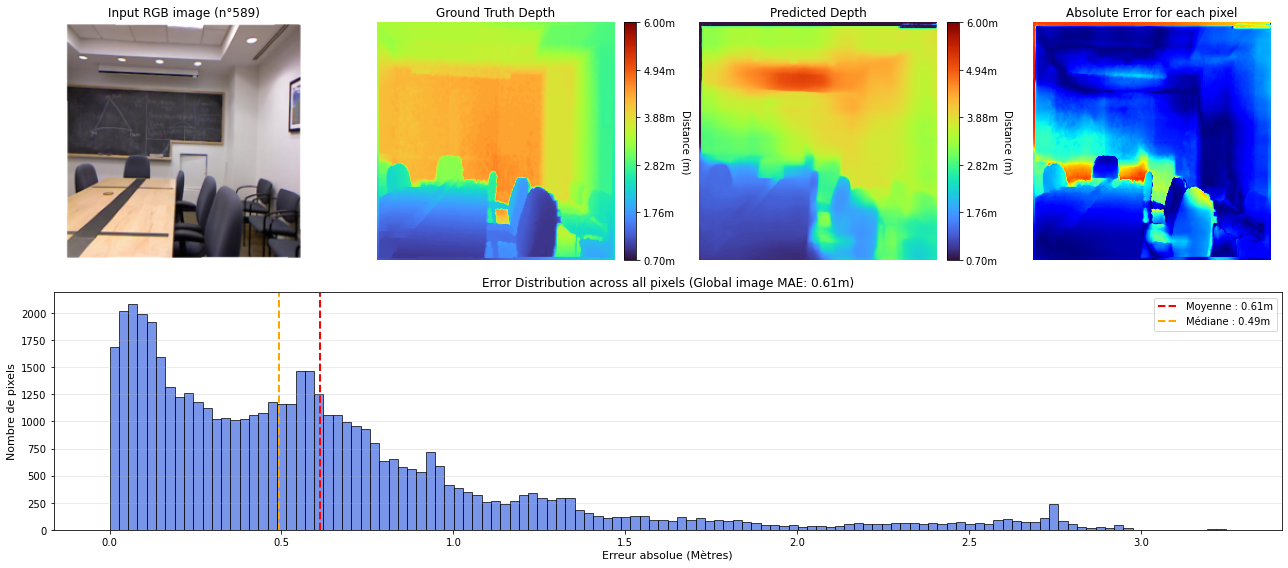

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from random import randint
from src.utils import predict

idx = randint(0, len(test_dataset)-1)
img, gnd_dep = test_dataset[idx]
gnd_dep_np = gnd_dep.squeeze().cpu().numpy()

pred_dep_m = predict(img, model, device)

gnd_dep_m = gnd_dep_np * (10.0 - 0.7) + 0.7
absolute_error_m = np.abs(pred_dep_m - gnd_dep_m)

mask = (gnd_dep_np > 0.01) & (gnd_dep_np < 0.99)
valid_errors = absolute_error_m[mask]

cmap = plt.get_cmap("turbo").copy()
cmap.set_bad(color="black")


mosaic = [
    ["rgb", "gnd", "pred", "err"],
    ["hist", "hist", "hist", "hist"]
]
fig, axs = plt.subplot_mosaic(mosaic, figsize=(18, 8))

axs["rgb"].set_title(f"Input RGB image (n°{idx})")
axs["rgb"].imshow((img.permute(1, 2, 0).cpu().numpy() + 1.0) / 2.0)
axs["rgb"].axis("off")

vmin_shared, vmax_shared = 0.7, 6.0
ticks_m = np.linspace(vmin_shared, vmax_shared, 6)
tick_labels = [f"{t:.2f}m" for t in ticks_m]

axs["gnd"].set_title("Ground Truth Depth")
im1 = axs["gnd"].imshow(gnd_dep_m, cmap=cmap, vmin=vmin_shared, vmax=vmax_shared)
axs["gnd"].axis("off")
cbar1 = fig.colorbar(im1, ax=axs["gnd"], orientation='vertical', fraction=0.046, pad=0.04)
cbar1.set_ticks(ticks_m)
cbar1.set_ticklabels(tick_labels)
cbar1.set_label('Distance (m)', rotation=270, labelpad=15)

axs["pred"].set_title("Predicted Depth")
im2 = axs["pred"].imshow(pred_dep_m, cmap=cmap, vmin=vmin_shared, vmax=vmax_shared)
axs["pred"].axis("off")
cbar2 = fig.colorbar(im2, ax=axs["pred"], orientation='vertical', fraction=0.046, pad=0.04)
cbar2.set_ticks(ticks_m)
cbar2.set_ticklabels(tick_labels)
cbar2.set_label('Distance (m)', rotation=270, labelpad=15)

axs["err"].set_title("Absolute Error for each pixel")
absolute_error_img = np.abs(pred_dep_m - gnd_dep_np)

im3 = axs["err"].imshow(absolute_error_m, cmap='jet', vmin=0, vmax=absolute_error_m.max())
axs["err"].axis("off")

mae_local = np.mean(valid_errors)
median_local = np.median(valid_errors)

axs["hist"].set_title(f"Error Distribution across all pixels (Global image MAE: {mae_local:.2f}m)")
axs["hist"].hist(valid_errors, bins=120, color='royalblue', edgecolor='black', alpha=0.7)

axs["hist"].axvline(mae_local, color='red', linestyle='dashed', linewidth=2, label=f'Moyenne : {mae_local:.2f}m')
axs["hist"].axvline(median_local, color='orange', linestyle='dashed', linewidth=2, label=f'Médiane : {median_local:.2f}m')

axs["hist"].set_xlabel("Erreur absolue (Mètres)", fontsize=11)
axs["hist"].set_ylabel("Nombre de pixels", fontsize=11)
axs["hist"].grid(axis='y', alpha=0.3)
axs["hist"].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [30]:
import numpy as np
from tqdm import tqdm
from src.utils import compute_ssim_numpy

SAMPLE_SIZE = 700
sample_size = min(SAMPLE_SIZE, len(test_dataset))
mae_list = []
mse_list = []
mae_m_list = []
mse_m_list = []
edges_list = []
ssim_list = []

for i in tqdm(range(0, sample_size), desc="Post Training Evaluation", unit="img"):

    img, y_true = test_dataset[i]
    y_true = y_true.squeeze().cpu().numpy()
    y_true = np.clip(y_true, 0.0, 1.0)

    y_m_pred = predict(img, model, device)

    y_m_true = y_true * (10.0 - 0.7) + 0.7
    y_pred = (y_m_pred - 0.7)/(10.0 - 0.7)

    mae_list.append(np.mean(np.abs(y_pred - y_true)))
    mae_m_list.append(np.mean(np.abs(y_m_pred - y_m_true)))
    mse_list.append(np.mean(np.power(y_pred - y_true, 2)))
    mse_m_list.append(np.mean(np.power(y_m_pred - y_m_true, 2)))

    dy_true = y_true[..., 1:, :] - y_true[..., :-1, :]
    dy_pred = y_pred[..., 1:, :] - y_pred[..., :-1, :]
    dx_true = y_true[..., :, 1:] - y_true[..., :, :-1]
    dx_pred = y_pred[..., :, 1:] - y_pred[..., :, :-1]
    edges_list.append(np.mean(np.abs(dy_pred - dy_true)) + np.mean(np.abs(dx_pred - dx_true)))
    y_true_ssim = y_true.squeeze()
    y_pred_ssim = y_pred.squeeze()
    ssim_list.append(compute_ssim_numpy(y_true_ssim, y_pred_ssim, data_range=1.0))

mae = np.sum(mae_list)/sample_size
mae_m = np.sum(mae_m_list)/sample_size
rmse = np.sqrt(np.sum(mse_list)/sample_size)
rmse_m = np.sqrt(np.sum(mse_m_list)/sample_size)
edges = np.sum(edges_list)/sample_size
ssim = np.sum(ssim_list)/sample_size

print("=== STATISTICS - POST TRAINING PERFORMANCES ===")
print(f"Sample size        : {sample_size}")
print(f"MAE                : {mae:.4f}")
print(f"MAE (m)            : {mae_m:.4f} m")
print(f"RMSE               : {rmse:.4f}")
print(f"RMSE (m)           : {rmse_m:.4f} m")
print(f"Edges              : {edges:.4f}")
print(f"SSIM               : {ssim:.4f}")

Post Training Evaluation: 100%|████████████████████████████████████████████████████████████████████████████████| 654/654 [00:42<00:00, 15.55img/s]

=== STATISTICS - POST TRAINING PERFORMANCES ===
Sample size        : 654
MAE                : 0.0644
MAE (m)            : 0.5991 m
RMSE               : 0.0989
RMSE (m)           : 0.9196 m
Edges              : 0.0078
SSIM               : 0.8140


<h2><b>Post Quantization Prediction</b></h2>

./models/MDE_UNET/build/quant_model
	|- Model :
	|	|- Loading checkpoint from './models/MDE_UNET/MDE_UNET.pth'...
	|	|- Model state restored successfully (epoch 23).
	|	|- Loading training history from './models/MDE_UNET/MDE_UNET_history.json'.

[VAIQ_WARN]: CUDA is not available, change device to CPU

[VAIQ_NOTE]: Quant config file is empty, use default quant configuration

[VAIQ_NOTE]: Quantization test process start up...

[VAIQ_NOTE]: =>Quant Module is in 'cpu'.

[VAIQ_NOTE]: =>Parsing UNet...

[VAIQ_NOTE]: Start to trace model...

[VAIQ_NOTE]: Finish tracing.

[VAIQ_NOTE]: Processing ops...


[autoreload of nndct_UNet failed: Traceback (most recent call last):
  File "/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/site-packages/IPython/extensions/autoreload.py", line 245, in check
    superreload(m, reload, self.old_objects)
  File "/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/site-packages/IPython/extensions/autoreload.py", line 394, in superreload
    module = reload(module)
  File "/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/imp.py", line 314, in reload
    return importlib.reload(module)
  File "/opt/vitis_ai/conda/envs/vitis-ai-pytorch/lib/python3.7/importlib/__init__.py", line 168, in reload
    raise ModuleNotFoundError(f"spec not found for the module {name!r}", name=name)
ModuleNotFoundError: spec not found for the module 'nndct_UNet'
]
██████████████████████████████████████████████████| 69/69 [00:00<00:00, 1582.45it/s, OpInfo: name = return_0, type = Return]                      


[VAIQ_NOTE]: =>Doing weights equalization...

[VAIQ_NOTE]: =>Quantizable module is generated.(./models/MDE_UNET/build/quant_model/UNet.py)

[VAIQ_NOTE]: =>Get module with quantization.


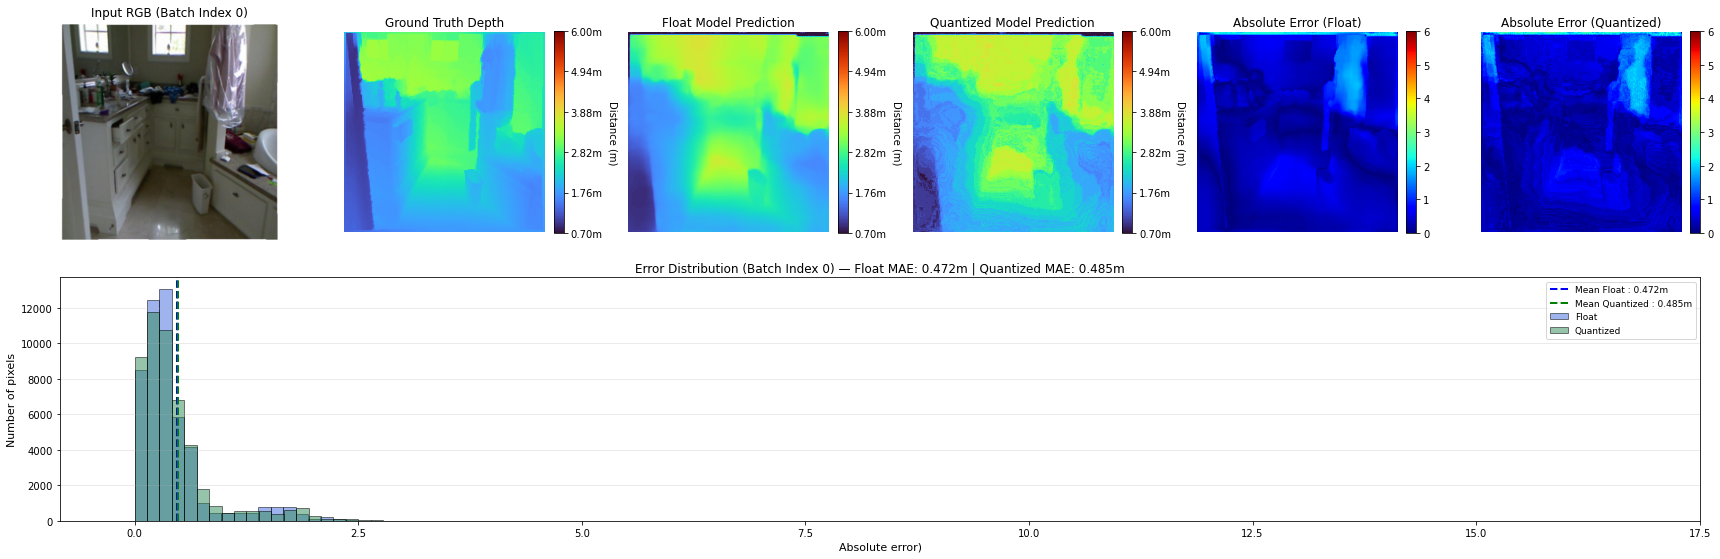

In [43]:
import torch
import random
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader
from pytorch_nndct.apis import torch_quantizer

from src.model import UNet

BATCH_SIZE = 1

build_dir = os.path.join(model_dir, "build")
quant_model_path = os.path.join(build_dir, "quant_model")
print(quant_model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, history = src.utils.load_for_eval(UNet, MODEL_NAME, device)
model.eval()

temp_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0,
    pin_memory=False
)

rand_in = torch.randn([BATCH_SIZE, 3, 224, 224])
quantizer = torch_quantizer(
    quant_mode='test', 
    module=model, 
    input_args=(rand_in), 
    output_dir=quant_model_path
)
quantized_model = quantizer.quant_model.to(device)
quantized_model.eval()

images_batch, depth_gt_batch = next(iter(temp_loader))
with torch.no_grad():
    depth_pred_float = model(images_batch.to(device))
    depth_pred_quant = quantized_model(images_batch.to(device))

actual_batch_size = images_batch.size(0)
num_examples = min(3, actual_batch_size)
random_indices = random.sample(range(actual_batch_size), num_examples)


for idx in random_indices:
    rgb_img = images_batch[idx].cpu().permute(1, 2, 0).numpy()
    rgb_min, rgb_max = rgb_img.min(), rgb_img.max()
    if rgb_max > rgb_min:
        rgb_img = (rgb_img - rgb_min) / (rgb_max - rgb_min)

    gt_depth_np = depth_gt_batch[idx].cpu().squeeze().numpy()
    float_depth_np = depth_pred_float[idx].cpu().squeeze().numpy()
    quant_depth_np = depth_pred_quant[idx].cpu().squeeze().numpy()

    # --- Conversion en mètres (même formule que le reste du pipeline) ---
    gt_depth_m = gt_depth_np * (10.0 - 0.7) + 0.7
    float_depth_m = float_depth_np * (10.0 - 0.7) + 0.7
    quant_depth_m = quant_depth_np * (10.0 - 0.7) + 0.7

    # --- Erreurs absolues en mètres ---
    error_float_m = np.abs(float_depth_m - gt_depth_m)
    error_quant_m = np.abs(quant_depth_m - gt_depth_m)

    mask = (gt_depth_np > 0.01) & (gt_depth_np < 0.99)
    valid_errors_float = error_float_m[mask]
    valid_errors_quant = error_quant_m[mask]

    cmap = plt.get_cmap("turbo").copy()
    cmap.set_bad(color="black")

    mosaic = [
        ["rgb", "gnd", "float", "quant", "err_float", "err_quant"],
        ["hist", "hist", "hist", "hist", "hist", "hist"]
    ]
    fig, axs = plt.subplot_mosaic(mosaic, figsize=(24, 8))

    # --- RGB ---
    axs["rgb"].set_title(f"Input RGB (Batch Index {idx})")
    axs["rgb"].imshow(rgb_img)
    axs["rgb"].axis("off")

    # --- Échelle partagée ---
    vmin_shared, vmax_shared = 0.7, 6.0
    ticks_m = np.linspace(vmin_shared, vmax_shared, 6)
    tick_labels = [f"{t:.2f}m" for t in ticks_m]

    # --- Ground Truth ---
    axs["gnd"].set_title("Ground Truth Depth")
    im1 = axs["gnd"].imshow(gt_depth_m, cmap=cmap, vmin=vmin_shared, vmax=vmax_shared)
    axs["gnd"].axis("off")
    cbar1 = fig.colorbar(im1, ax=axs["gnd"], orientation='vertical', fraction=0.046, pad=0.04)
    cbar1.set_ticks(ticks_m)
    cbar1.set_ticklabels(tick_labels)
    cbar1.set_label('Distance (m)', rotation=270, labelpad=15)

    # --- Float Model Prediction ---
    axs["float"].set_title("Float Model Prediction")
    im2 = axs["float"].imshow(float_depth_m, cmap=cmap, vmin=vmin_shared, vmax=vmax_shared)
    axs["float"].axis("off")
    cbar2 = fig.colorbar(im2, ax=axs["float"], orientation='vertical', fraction=0.046, pad=0.04)
    cbar2.set_ticks(ticks_m)
    cbar2.set_ticklabels(tick_labels)
    cbar2.set_label('Distance (m)', rotation=270, labelpad=15)

    # --- Quantized Model Prediction ---
    axs["quant"].set_title("Quantized Model Prediction")
    im3 = axs["quant"].imshow(quant_depth_m, cmap=cmap, vmin=vmin_shared, vmax=vmax_shared)
    axs["quant"].axis("off")
    cbar3 = fig.colorbar(im3, ax=axs["quant"], orientation='vertical', fraction=0.046, pad=0.04)
    cbar3.set_ticks(ticks_m)
    cbar3.set_ticklabels(tick_labels)
    cbar3.set_label('Distance (m)', rotation=270, labelpad=15)

    # --- Erreur absolue - Float ---
    axs["err_float"].set_title("Absolute Error (Float)")
    im4 = axs["err_float"].imshow(error_float_m, cmap='jet', vmin=0, vmax=vmax_shared)
    axs["err_float"].axis("off")
    fig.colorbar(im4, ax=axs["err_float"], orientation='vertical', fraction=0.046, pad=0.04)

    # --- Erreur absolue - Quantized ---
    axs["err_quant"].set_title("Absolute Error (Quantized)")
    im5 = axs["err_quant"].imshow(error_quant_m, cmap='jet', vmin=0, vmax=vmax_shared)
    axs["err_quant"].axis("off")
    fig.colorbar(im5, ax=axs["err_quant"], orientation='vertical', fraction=0.046, pad=0.04)

    # --- Histogramme comparatif Float vs Quantized ---
    mae_float = np.mean(valid_errors_float)
    mae_quant = np.mean(valid_errors_quant)
    median_float = np.median(valid_errors_float)
    median_quant = np.median(valid_errors_quant)

    axs["hist"].set_title(
        f"Error Distribution (Batch Index {idx}) — "
        f"Float MAE: {mae_float:.3f}m | Quantized MAE: {mae_quant:.3f}m"
    )
    axs["hist"].hist(valid_errors_float, bins=120, color='royalblue', edgecolor='black', alpha=0.5, label='Float')
    axs["hist"].hist(valid_errors_quant, bins=120, color='seagreen', edgecolor='black', alpha=0.5, label='Quantized')
    axs["hist"].axvline(mae_float, color='blue', linestyle='dashed', linewidth=2, label=f'Mean Float : {mae_float:.3f}m')
    axs["hist"].axvline(mae_quant, color='green', linestyle='dashed', linewidth=2, label=f'Mean Quantized : {mae_quant:.3f}m')
    axs["hist"].set_xlabel("Absolute error)", fontsize=11)
    axs["hist"].set_ylabel("Number of pixels", fontsize=11)
    axs["hist"].grid(axis='y', alpha=0.3)
    axs["hist"].legend(fontsize=9)

    plt.tight_layout()
    save_path = os.path.join(outputs_dir_path, "comparaison_float_quant_idx.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [46]:
import numpy as np
from tqdm import tqdm
from src.utils import compute_ssim_numpy


SAMPLE_SIZE_LIMIT = 700
total_samples = min(SAMPLE_SIZE_LIMIT, len(test_dataset))

def run_evaluation_pass(eval_model, name="Model"):
    mae_list, mse_list = [], []
    mae_m_list, mse_m_list = [], []
    edges_list, ssim_list = [], []

    eval_model.eval()
    with torch.no_grad():
        for i in tqdm(range(total_samples), desc=f"Evaluating {name[:15]}"):
            img_tensor, y_true_tensor = test_dataset[i]

            y_true = y_true_tensor.squeeze().cpu().numpy()
            y_true = np.clip(y_true, 0.0, 1.0)

            img_input = img_tensor.unsqueeze(0).to(device)
            pred_tensor = eval_model(img_input)
            y_pred = pred_tensor.squeeze().cpu().numpy()
            y_pred = np.clip(y_pred, 0.0, 1.0)

            y_m_true = y_true * (10.0 - 0.7) + 0.7
            y_m_pred = y_pred * (10.0 - 0.7) + 0.7

            mae_list.append(np.mean(np.abs(y_pred - y_true)))
            mae_m_list.append(np.mean(np.abs(y_m_pred - y_m_true)))
            mse_list.append(np.mean(np.power(y_pred - y_true, 2)))
            mse_m_list.append(np.mean(np.power(y_m_pred - y_m_true, 2)))

            dy_true = y_true[..., 1:, :] - y_true[..., :-1, :]
            dy_pred = y_pred[..., 1:, :] - y_pred[..., :-1, :]
            dx_true = y_true[..., :, 1:] - y_true[..., :, :-1]
            dx_pred = y_pred[..., :, 1:] - y_pred[..., :, :-1]
            edges_list.append(np.mean(np.abs(dy_pred - dy_true)) + np.mean(np.abs(dx_pred - dx_true)))

            ssim_list.append(compute_ssim_numpy(y_true.squeeze(), y_pred.squeeze(), data_range=1.0))

    return {
        "MAE": np.sum(mae_list) / total_samples,
        "MAE (m)": np.sum(mae_m_list) / total_samples,
        "MSE": np.sqrt(np.sum(mse_list) / total_samples),
        "MSE (m)": np.sqrt(np.sum(mse_m_list) / total_samples),
        "Edges": np.sum(edges_list) / total_samples,
        "SSIM": np.sum(ssim_list) / total_samples
    }


float_metrics = run_evaluation_pass(model, name="Float Baseline Model")
quant_metrics = run_evaluation_pass(quantized_model, name="Vitis-AI Quantized Model")


print("\n" + "=" * 65)
print(f"{'METRIC':<15} | {'FLOAT BASELINE':<16} | {'QUANTIZED INT8':<16} | {'DELTA':<10}")
print("=" * 65)
for metric_key in float_metrics.keys():
    f_val = float_metrics[metric_key]
    q_val = quant_metrics[metric_key]
    delta = q_val - f_val

    unit = " m" if "(m)" in metric_key else ""
    f_str = f"{f_val:.4f}{unit}"
    q_str = f"{q_val:.4f}{unit}"

    print(f"{metric_key:<15} | {f_str:<16} | {q_str:<16} | {delta:+.4f}")
print("=" * 65)

Evaluating Vitis-AI Quanti: 100%|███████████████████████████████████████████████████████████████████████████████| 654/654 [01:53<00:00,  5.78it/s]


METRIC          | FLOAT BASELINE   | QUANTIZED INT8   | DELTA     
MAE             | 0.0644           | 0.0655           | +0.0011
MAE (m)         | 0.5991 m         | 0.6089 m         | +0.0098
MSE             | 0.0989           | 0.0994           | +0.0005
MSE (m)         | 0.9196 m         | 0.9245 m         | +0.0049
Edges           | 0.0078           | 0.0174           | +0.0096
SSIM            | 0.8140           | 0.7455           | -0.0685
